# 第028讲 一元线性回归的完整推导

## 目标
从五个点的手算开始，核验纯代数最优解、残差恒等式和模型失败边界。全部数据为原创合成教学数据，单位采用 N 与 V，不代表真实传感器性能。

已保留的结果：截距 3/5，斜率 6/5，SSE 8/5，MSE 8/25。曲线例最佳直线仍留下 U 形残差；增加 (20,0) 后斜率改变符号。已知正态模型内的不确定性不能覆盖未知的外推机制。

先修：第008与013讲。似然部分在第023讲之后阅读。先自行手算，再执行代码。

## 环境
这是固定默认输入的教学Notebook，首格在任何数值输出或图之前核对两份输入字节；自定义数据或配置请运行通用experiment.py。
从本讲目录打开。重启内核并依次执行所有单元。制作时以新进程中的真实 ipykernel InProcessKernel 执行并保留输出；普通 socket 内核传输受限，未验证浏览器 Jupyter 界面或实际 Anaconda 安装。此说明不影响下面代码在已配置本地 Python 内核中的顺序运行。

In [1]:
%matplotlib inline
from pathlib import Path
from fractions import Fraction as F
from decimal import Decimal, localcontext
import json, math, tempfile, sys
import numpy as np
import matplotlib.pyplot as plt
import experiment as e
e.check_notebook_baseline()
plt.rcParams.update({'figure.figsize': (9, 3.5), 'font.size': 11, 'axes.spines.top': False, 'axes.spines.right': False})
print({'python': sys.version.split()[0], 'numpy': np.__version__, 'data_available': (e.ROOT/'data/cases.csv').exists()})

{'python': '3.12.14', 'numpy': '2.3.5', 'data_available': True}


## 步骤 1 读取全部数据
每组独立拟合。focus_case 只决定候选比较关注哪里，不允许跳过其他组的输入检查。所有原始数值先验证再转浮点。

In [2]:
groups = e.read_cases(e.ROOT/'data/cases.csv')
config = e.read_config(e.ROOT/'data/model_spec.json')
x, y = groups['hand']['x'], groups['hand']['y']
print({key: len(row['x']) for key, row in groups.items()})
print('Hand observations:', list(zip(x, y)))
print('Known sigma, simulation repeats:', config['known_sigma'], config['simulation_repeats'])

{'hand': 5, 'curved': 7, 'influential': 6, 'perfect': 4, 'constant_x': 3}
Hand observations: [(0.0, 1.0), (1.0, 2.0), (2.0, 2.0), (3.0, 4.0), (4.0, 6.0)]
Known sigma, simulation repeats: 1.0 600


## 步骤 2 独立有理数手算
这里的 Fraction 是核验工具。fit_line 故意不接收外部精确数值类型，避免隐式降精度。

In [3]:
xq, yq = [F.from_float(v) for v in x], [F.from_float(v) for v in y]
xbar, ybar = sum(xq)/len(xq), sum(yq)/len(yq)
sxx = sum((v-xbar)**2 for v in xq)
sxy = sum((v-xbar)*(w-ybar) for v,w in zip(xq,yq))
bq = sxy/sxx; aq = ybar-bq*xbar
rq = [v-aq-bq*t for t,v in zip(xq,yq)]
sseq = sum(v*v for v in rq)
print({'a':str(aq),'b':str(bq),'Sxx':str(sxx),'Sxy':str(sxy),'SSE':str(sseq),'MSE':str(sseq/len(xq))})
print('Residuals:', [str(v) for v in rq])
print('Exact orthogonality:', sum(rq), sum(t*v for t,v in zip(xq,rq)))

{'a': '3/5', 'b': '6/5', 'Sxx': '10', 'Sxy': '12', 'SSE': '8/5', 'MSE': '8/25'}
Residuals: ['2/5', '1/5', '-1', '-1/5', '3/5']
Exact orthogonality: 0 0


## 步骤 3 浮点实现和库核验
对本例温和尺度，三条路线应在小容差内一致。NumPy 的数值秩受 rcond 影响；这个核验不证明任意尺度都可靠。

In [4]:
model = e.fit_line(x,y)
A = np.column_stack([np.ones(len(x)), x])
coefficients, _, rank, _ = np.linalg.lstsq(A, y, rcond=None)
np.testing.assert_allclose([model['intercept'],model['slope']], [float(aq),float(bq)], rtol=1e-12,atol=1e-12)
np.testing.assert_allclose(coefficients,[float(aq),float(bq)],rtol=1e-12,atol=1e-12)
print({'float_a':model['intercept'],'float_b':model['slope'],'numpy_coefficients':coefficients.tolist(),'rank':int(rank),'SSE':model['sse'],'MSE':model['mse']})

{'float_a': 0.6000000000000001, 'float_b': 1.2, 'numpy_coefficients': [0.5999999999999993, 1.2000000000000004], 'rank': 2, 'SSE': 1.6, 'MSE': 0.32}


## 步骤 4 画原始点和残差
竖线为纵向残差，不是点到直线的最短距离。右图必须保留符号，才能读出高估或低估。

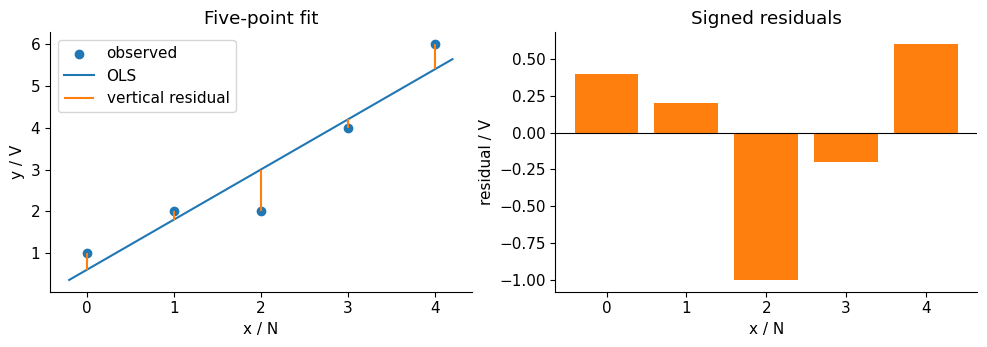

In [5]:
fig, ax = plt.subplots(1,2,figsize=(10,3.6))
grid = np.linspace(-.2,4.2,120)
ax[0].scatter(x,y,label='observed');ax[0].plot(grid,.6+1.2*grid,label='OLS')
ax[0].vlines(x,model['fitted'],y,color='tab:orange',label='vertical residual')
ax[0].set(xlabel='x / N',ylabel='y / V',title='Five-point fit');ax[0].legend()
ax[1].bar(x,model['residuals'],color='tab:orange');ax[1].axhline(0,color='black',lw=.8)
ax[1].set(xlabel='x / N',ylabel='residual / V',title='Signed residuals')
fig.tight_layout();plt.show()

## 步骤 5 检查全局配平方恒等式
网格只核验程序，不代替对所有参数成立的代数证明。两张切片展示最优截距与最优斜率的不同角色。

Largest finite-grid identity error: 1.4210854715202004e-14


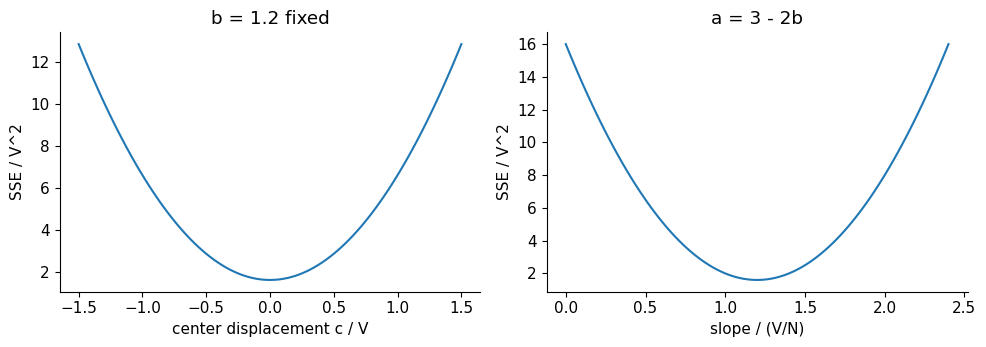

In [6]:
errors=[]
for a in np.linspace(-1,2,9):
    for b in np.linspace(0,2,11):
        direct=e.evaluate_line(x,y,a,b)['sse']
        identity=1.6+5*(a+2*b-3)**2+10*(b-1.2)**2
        errors.append(abs(direct-identity))
print('Largest finite-grid identity error:',max(errors))
if max(errors)>1e-11:raise RuntimeError('completion identity failed')
fig,ax=plt.subplots(1,2,figsize=(10,3.6));c=np.linspace(-1.5,1.5,100);b=np.linspace(0,2.4,100)
ax[0].plot(c,1.6+5*c*c);ax[0].set(xlabel='center displacement c / V',ylabel='SSE / V^2',title='b = 1.2 fixed')
ax[1].plot(b,1.6+10*(b-1.2)**2);ax[1].set(xlabel='slope / (V/N)',ylabel='SSE / V^2',title='a = 3 - 2b')
fig.tight_layout();plt.show()

## 步骤 6 候选排序与平方和分解
SSE、MSE 的排序应相同。Syy 等于拟合部分加残差部分，依赖带截距的最优拟合。

In [7]:
candidates=[e.evaluate_line(x,y,**{'a':row['intercept'],'b':row['slope']}) for row in config['candidate_lines']]
for row in candidates:print({key:row[key] for key in ['intercept','slope','sse','mse']})
print('Same ordering:', np.array_equal(np.argsort([r['sse'] for r in candidates]),np.argsort([r['mse'] for r in candidates])))
print({key:model[key] for key in ['Syy','explained_ss','sse','decomposition_error','residual_sum','centered_x_residual_sum','r_squared']})

{'intercept': 0.6, 'slope': 1.2, 'sse': 1.5999999999999999, 'mse': 0.31999999999999995}
{'intercept': 1.0, 'slope': 1.0, 'sse': 2.0, 'mse': 0.4}
{'intercept': 3.0, 'slope': 0.0, 'sse': 16.0, 'mse': 3.2}
{'intercept': 0.0, 'slope': 1.2, 'sse': 3.400000000000001, 'mse': 0.6800000000000002}
Same ordering: True
{'Syy': 16.0, 'explained_ss': 14.399999999999999, 'sse': 1.6, 'decomposition_error': 1.3322676295501878e-15, 'residual_sum': 0.0, 'centered_x_residual_sum': 4.440892098500626e-16, 'r_squared': 0.9}


## 步骤 7 常数输入的参数族
代表解的零斜率是输出约定。图中三条最优线在 x=2 处相交，数据没有识别其他位置的预测。

{'intercept': 2.3333333333333335, 'slope': 0.0, 'unique_parameters': False, 'sse': 4.666666666666667}


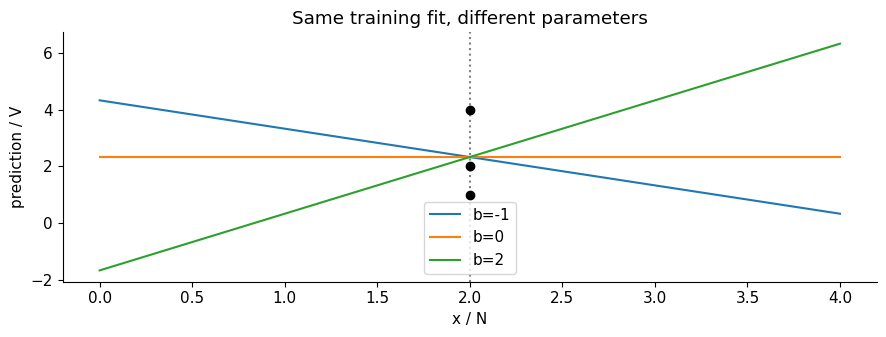

In [8]:
k=groups['constant_x']; km=e.fit_line(k['x'],k['y'])
print({key:km[key] for key in ['intercept','slope','unique_parameters','sse']})
fig,ax=plt.subplots();t=np.linspace(0,4,100)
for slope in [-1,0,2]:ax.plot(t,7/3+slope*(t-2),label=f'b={slope}')
ax.scatter(k['x'],k['y'],color='black',zorder=4);ax.axvline(2,color='gray',ls=':')
ax.set(xlabel='x / N',ylabel='prediction / V',title='Same training fit, different parameters');ax.legend();fig.tight_layout();plt.show()

## 步骤 8 已知正态噪声的似然
以下计算条件于固定 x，并假设独立、同方差、零均值正态误差。没有这些条件，平方损失仍能优化，但不能沿用同一个概率解释。

In [9]:
sigma=config['known_sigma']
nll=[e.gaussian_nll(x,y,row['intercept'],row['slope'],sigma) for row in config['candidate_lines']]
print('Candidate NLL:',nll)
np.testing.assert_allclose(np.array(nll)-nll[0],(np.array([r['sse'] for r in candidates])-candidates[0]['sse'])/(2*sigma*sigma),atol=1e-12)
perfect=groups['perfect'];pm=e.fit_line(perfect['x'],perfect['y'])
print('Positive SSE variance MLE:',model['variance_mle'])
print('Perfect fit:',{key:pm[key] for key in ['sse','exact_minimum_sse_zero','variance_mle','variance_mle_status']})

Candidate NLL: [5.394692666023363, 5.594692666023363, 12.594692666023363, 6.294692666023363]
Positive SSE variance MLE: 0.32
Perfect fit: {'sse': 0.0, 'exact_minimum_sse_zero': True, 'variance_mle': None, 'variance_mle_status': 'no_finite_maximum_sigma_to_zero'}


## 步骤 9 未知方差剖面
左图在正方差 0.32 处达到最优。右图在每个绘出的正方差处仍能继续向左改善，不存在 sigma=0 的普通正态密度。

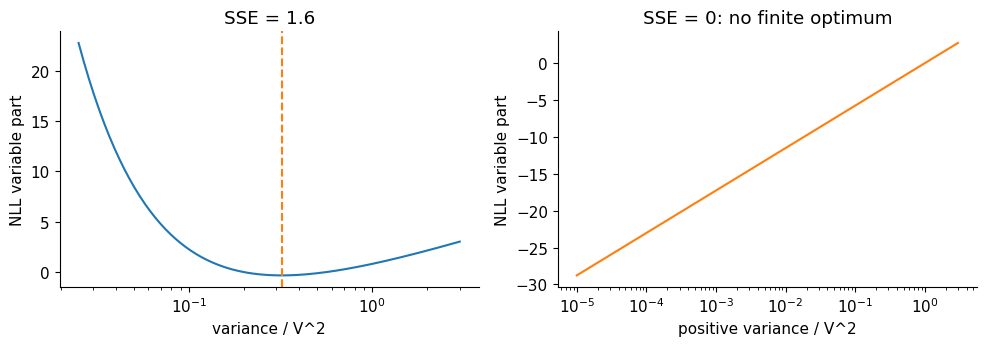

In [10]:
fig,ax=plt.subplots(1,2,figsize=(10,3.6));v=np.geomspace(.025,3,150)
ax[0].semilogx(v,2.5*np.log(v)+.8/v);ax[0].axvline(.32,color='tab:orange',ls='--')
ax[0].set(xlabel='variance / V^2',ylabel='NLL variable part',title='SSE = 1.6')
v0=np.geomspace(1e-5,3,150);ax[1].semilogx(v0,2.5*np.log(v0),color='tab:orange')
ax[1].set(xlabel='positive variance / V^2',ylabel='NLL variable part',title='SSE = 0: no finite optimum')
fig.tight_layout();plt.show()

## 步骤 10 仿射变换
先手算 x′=60x+10，y′=1000y+100 的新截距与斜率，再执行。单位变化与偏移必须一起进入公式。

In [11]:
transformed=e.fit_line([60*v+10 for v in x],[1000*v+100 for v in y])
np.testing.assert_allclose([transformed['intercept'],transformed['slope']],[500,20],atol=1e-10)
np.testing.assert_allclose(transformed['sse'],1e6*model['sse'],rtol=1e-12)
print({key:transformed[key] for key in ['intercept','slope','sse']})
print('Back-converted fitted values:',[(v-100)/1000 for v in transformed['fitted']])

{'intercept': 500.0, 'slope': 20.0, 'sse': 1600000.0}
Back-converted fitted values: [0.6, 1.8, 3.0, 4.2, 5.4]


## 步骤 11 非线性反例
这组数据完全由确定的二次函数生成，没有随机误差。残差正交仍然成立，但 U 形说明直线遗漏了均值结构。

{'intercept': 3.0, 'slope': 1.0, 'sse': 21.0, 'residual_sum': 0.0, 'centered_x_residual_sum': 0.0}


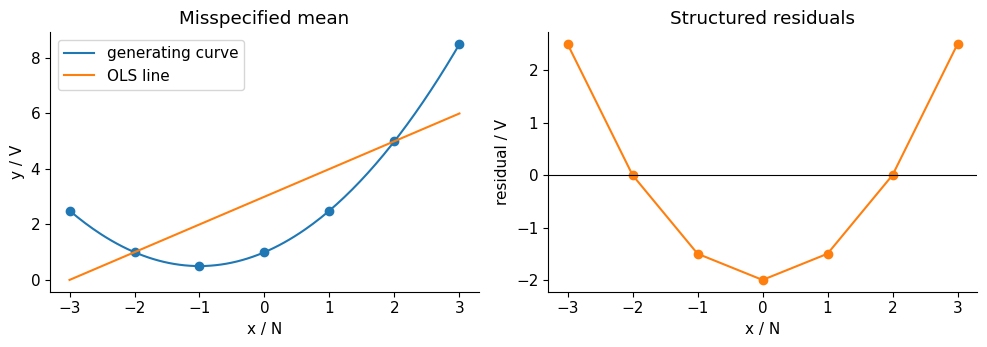

In [12]:
c=groups['curved'];cm=e.fit_line(c['x'],c['y'])
print({key:cm[key] for key in ['intercept','slope','sse','residual_sum','centered_x_residual_sum']})
fig,ax=plt.subplots(1,2,figsize=(10,3.6));t=np.linspace(-3,3,150)
ax[0].scatter(c['x'],c['y']);ax[0].plot(t,1+t+.5*t*t,label='generating curve');ax[0].plot(t,3+t,label='OLS line');ax[0].legend()
ax[0].set(xlabel='x / N',ylabel='y / V',title='Misspecified mean')
ax[1].plot(c['x'],cm['residuals'],'o-',color='tab:orange');ax[1].axhline(0,color='black',lw=.8)
ax[1].set(xlabel='x / N',ylabel='residual / V',title='Structured residuals')
fig.tight_layout();plt.show()

## 步骤 12 远端点的实际影响
新增一行后斜率反向。高杠杆点的拟合残差可能很小，因此需要同时查输入布局和删点敏感性，不能按残差大小机械清洗。

{'new_slope': -0.11785714285714285, 'new_intercept': 3.0892857142857144, 'last_leverage': 0.9702380952380952, 'last_residual': -0.7321428571428572}


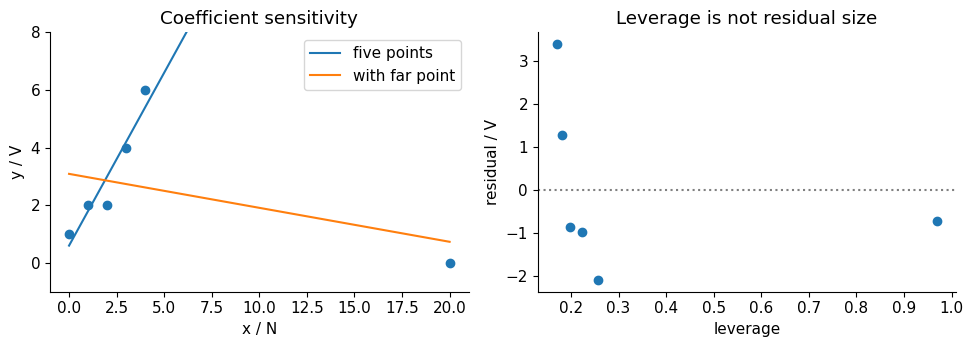

In [13]:
v=groups['influential'];im=e.fit_line(v['x'],v['y'])
print({'new_slope':im['slope'],'new_intercept':im['intercept'],'last_leverage':im['leverage'][-1],'last_residual':im['residuals'][-1]})
fig,ax=plt.subplots(1,2,figsize=(10,3.6));t=np.linspace(0,20,120)
ax[0].scatter(v['x'],v['y']);ax[0].plot(t,.6+1.2*t,label='five points');ax[0].plot(t,im['intercept']+im['slope']*t,label='with far point');ax[0].set_ylim(-1,8);ax[0].legend()
ax[0].set(xlabel='x / N',ylabel='y / V',title='Coefficient sensitivity')
ax[1].scatter(im['leverage'],im['residuals']);ax[1].axhline(0,color='gray',ls=':');ax[1].set(xlabel='leverage',ylabel='residual / V',title='Leverage is not residual size')
fig.tight_layout();plt.show()

## 步骤 13 插值和外推
模型内标准误依赖同方差独立误差与正确均值函数。右图两种机制在训练区间内相同，区间外分离，提示额外模型偏差。

{'x': 2.5, 'prediction': 3.6, 'outside_training_range': False, 'conditional_mean_se_if_model_true': 0.4743416490252569, 'new_observation_sd_if_model_true': 1.1067971810589328}
{'x': 6.0, 'prediction': 7.8, 'outside_training_range': True, 'conditional_mean_se_if_model_true': 1.3416407864998738, 'new_observation_sd_if_model_true': 1.6733200530681511}


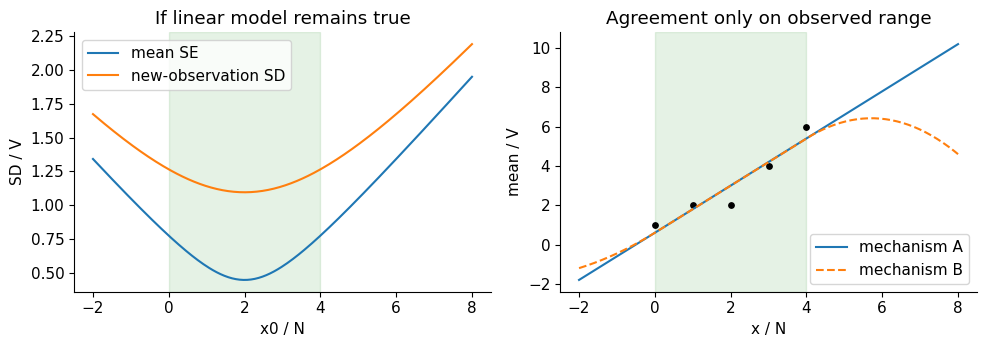

In [14]:
predictions=e.prediction_diagnostics(x,y,config['prediction_x'],sigma)
for row in predictions:print(row)
fig,ax=plt.subplots(1,2,figsize=(10,3.6));t=np.linspace(-2,8,200);se=np.sqrt(.2+(t-2)**2/10)
ax[0].plot(t,se,label='mean SE');ax[0].plot(t,np.sqrt(1+se*se),label='new-observation SD');ax[0].axvspan(0,4,color='green',alpha=.1);ax[0].legend();ax[0].set(xlabel='x0 / N',ylabel='SD / V',title='If linear model remains true')
mu=.6+1.2*t;alternative=mu-.35*np.maximum(t-4,0)**2+.15*np.maximum(-t,0)**2
ax[1].plot(t,mu,label='mechanism A');ax[1].plot(t,alternative,'--',label='mechanism B');ax[1].axvspan(0,4,color='green',alpha=.1);ax[1].scatter(x,y,s=15,color='black');ax[1].legend();ax[1].set(xlabel='x / N',ylabel='mean / V',title='Agreement only on observed range')
fig.tight_layout();plt.show()

## 步骤 14 重复实验的理论与模拟
输入固定，真实参数固定，只有误差重新抽样。理论斜率标准差为 sigma/√Sxx。600次模拟有 Monte Carlo 误差，不要求样本标准差等于理论值。

{'repeats': 600, 'mean_slope': 1.2039519955931208, 'sample_slope_sd': 0.3025747321561816, 'theoretical_sd': 0.31622776601683794}


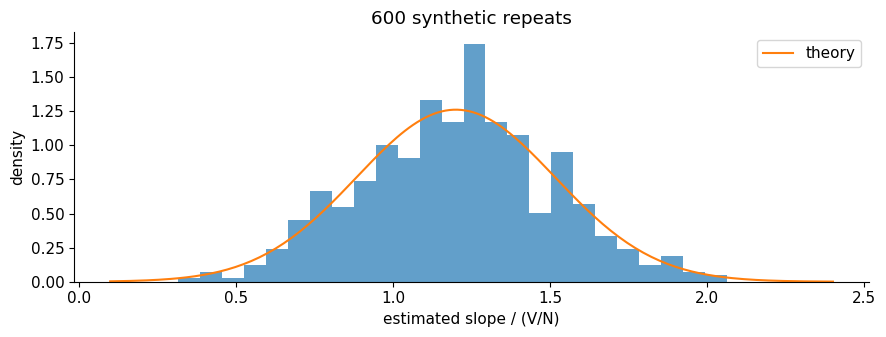

In [15]:
rng=np.random.default_rng(config['seed']);xx=np.array(x);dx=xx-model['x_mean']
noise=rng.normal(0,sigma,(config['simulation_repeats'],len(x)))
slopes=1.2+(noise@dx)/model['Sxx'];theoretical=sigma/math.sqrt(model['Sxx'])
print({'repeats':len(slopes),'mean_slope':float(slopes.mean()),'sample_slope_sd':float(slopes.std(ddof=1)),'theoretical_sd':theoretical})
fig,ax=plt.subplots();ax.hist(slopes,bins=25,density=True,alpha=.7)
z=np.linspace(.1,2.4,180);ax.plot(z,np.exp(-.5*((z-1.2)/theoretical)**2)/(theoretical*np.sqrt(2*np.pi)),label='theory')
ax.set(xlabel='estimated slope / (V/N)',ylabel='density',title='600 synthetic repeats');ax.legend();fig.tight_layout();plt.show()

## 检查 1 原始类型与极小词元
验证用显式异常控制，不依赖 assert。已有数组只能检验当前保存的类型和值，不能追溯外部转换前的信息。

In [16]:
rejections=[]
for label,call in [
    ('mixed bool',lambda:e.fit_line([0,False],[1,2])),
    ('complex',lambda:e.fit_line([0,1+0j],[1,2])),
    ('last prediction bool',lambda:e.prediction_diagnostics(x,y,[2,False],1)),
    ('tiny nonzero token',lambda:e.number_token('1e-400')),
    ('unsupported exact input',lambda:e.fit_line([F(0),F(1)],[1,2]))]:
    try:call()
    except ValueError:rejections.append(label)
    else:raise RuntimeError('Expected rejection: '+label)
print('Rejected:',rejections)
print('Genuine zero token:',e.number_token('0e-400'))

Rejected: ['mixed bool', 'complex', 'last prediction bool', 'tiny nonzero token', 'unsupported exact input']
Genuine zero token: 0.0


## 检查 2 原值求和与锚点丢失
对极小的正确结果使用绝对容差 1e−12 会把零也判为正确，因此这里直接比较预期浮点值。

In [17]:
small=[-1.,1.,1e-100]
original=e.fit_line(small,[1,1,1])['x_mean']
anchored=-1+math.fsum(v+1 for v in small)/3
with localcontext() as context:
    context.prec=130
    oracle_mean=sum(Decimal.from_float(v) for v in small)/3
print({'original_fsum_mean':original,'anchor_mean':anchored,'decimal_reference':str(oracle_mean)})
if original!=1e-100/3 or anchored!=0:raise RuntimeError('mean regression check changed')

{'original_fsum_mean': 3.3333333333333336e-101, 'anchor_mean': 0.0, 'decimal_reference': '3.33333333333333339997299934200961206549253596178053140060867668645531899751847822539225429537764329860915358270303950266176090180E-101'}


## 检查 3 坏末行不覆盖已有输出
在临时目录写一个哨兵报告，故意损坏没有被选择的 constant_x 最后一行。失败后比对原字节，不修改公开教学数据。

In [18]:
with tempfile.TemporaryDirectory() as directory:
    temporary=Path(directory);output=temporary/'report.json';bad_csv=temporary/'cases.csv'
    sentinel=b'previous valid report';output.write_bytes(sentinel)
    source=(e.ROOT/'data/cases.csv').read_text()
    bad_csv.write_text(source.replace('K03,2,4','K03,2,1e-400'))
    try:e.run(bad_csv,e.ROOT/'data/model_spec.json',output)
    except ValueError:pass
    else:raise RuntimeError('bad final row was accepted')
    preserved=output.read_bytes()==sentinel
    if not preserved:raise RuntimeError('previous report changed')
print('Previous output preserved after invalid final row:',preserved)

Previous output preserved after invalid final row: True


## 最终运行与下一步
现在生成完整报告。所有小型实验展示有限机制，不作为真实数据性能证据。检查 report.json 中的每组拟合、候选损失、预测风险标志与模拟配置。

In [19]:
report=e.run()
np.testing.assert_allclose(report['fits']['hand']['sse'],float(sseq),atol=1e-12)
print({'report_written':(e.ROOT/'outputs/report.json').exists(),'cases':list(report['fits']),'hand_SSE':report['fits']['hand']['sse'],'simulation':report['simulation']})

{'report_written': True, 'cases': ['hand', 'curved', 'influential', 'perfect', 'constant_x'], 'hand_SSE': 1.6, 'simulation': {'model': 'Y=0.6+1.2*x+iid Normal(0,known_sigma^2), fixed hand x', 'repeats': 600, 'seed': 20261004, 'slope_average': 1.2039519955931208, 'slope_sample_sd': 0.3025747321561816, 'theoretical_slope_sd': 0.31622776601683794}}


## 结论
五点手算、浮点拟合和 NumPy 核验一致。中心化配平方解释全局唯一性，常数输入需要参数族，未知正方差高斯模型遇到完美拟合没有有限最大似然解。曲线残差、远端点影响和外推机制分别揭示不同风险。

这里的斜率是合成数据的拟合关联。没有实际干预设计或新范围数据，不能把它当成真实因果效应或无条件外推保证。

延伸阅读与来源核验见 lecture.pdf 第22节和 source-checks.json；完整纸笔练习解答见 answers.pdf。